In [2]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import subprocess
plt.rcParams['svg.fonttype'] = 'none'

In [45]:
from scipy.stats import f_oneway, ttest_rel

def append_best_model_points_to_aggregate(
    aggregated_compare_df: pd.DataFrame,
    best_arch_across_groups_df: pd.DataFrame,
    merged_df: pd.DataFrame,
    embeddings_x,
    embeddings_y,
    ohe_x,
    ohe_y,
    source_group: str,
):
    target_models = ["delta_embeddings", "embeddings", "ohe"]

    score_df = (
        merged_df
        .drop_duplicates(subset=["model", "architecture", "evaluated_test_mutation"])
        .reset_index(drop=True)
    )

    architecture_summary = (
        score_df
        .groupby(["model", "architecture"], as_index=False)
        .agg(
            avg_test_spearman=("test_spearman", "mean"),
            std_test_spearman=("test_spearman", "std"),
            n_points=("test_spearman", "size"),
        )
    )

    best_arch_df = (
        architecture_summary
        .loc[architecture_summary.groupby("model")["avg_test_spearman"].idxmax()]
        .reset_index(drop=True)
    )

    best_arch_df["model"] = pd.Categorical(
        best_arch_df["model"],
        categories=target_models,
        ordered=True,
    )
    best_arch_df = best_arch_df.sort_values("model").reset_index(drop=True)
    best_arch_df["source_group"] = source_group

    def get_best_arch_points(model_name: str):
        row = best_arch_df[best_arch_df["model"] == model_name].iloc[0]
        arch = row["architecture"]
        avg_score = row["avg_test_spearman"]

        df = (
            score_df[
                (score_df["model"] == model_name) &
                (score_df["architecture"] == arch)
            ][["evaluated_test_mutation", "test_spearman"]]
            .sort_values("evaluated_test_mutation")
            .reset_index(drop=True)
        )
        return arch, avg_score, df

    delta_arch, delta_avg, delta_df = get_best_arch_points("delta_embeddings")
    emb_arch, emb_avg, emb_df = get_best_arch_points("embeddings")
    ohe_arch, ohe_avg, ohe_df = get_best_arch_points("ohe")

    compare_slice_df = pd.concat(
        [
            pd.DataFrame({
                "source_group": source_group,
                "comparison_group": "best_delta_embeddings",
                "display_group": "Best Delta Embeddings",
                "model": "delta_embeddings",
                "architecture": delta_arch,
                "evaluated_test_mutation": delta_df["evaluated_test_mutation"].values,
                "test_spearman": delta_df["test_spearman"].values,
                "best_arch_avg_test_spearman": delta_avg,
            }),
            pd.DataFrame({
                "source_group": source_group,
                "comparison_group": "best_embeddings",
                "display_group": "Best Embeddings",
                "model": "embeddings",
                "architecture": emb_arch,
                "evaluated_test_mutation": emb_df["evaluated_test_mutation"].values,
                "test_spearman": emb_df["test_spearman"].values,
                "best_arch_avg_test_spearman": emb_avg,
            }),
            pd.DataFrame({
                "source_group": source_group,
                "comparison_group": "embeddings_baseline",
                "display_group": "Embeddings Baseline",
                "model": "embeddings_baseline",
                "architecture": "baseline",
                "evaluated_test_mutation": np.asarray(embeddings_x),
                "test_spearman": np.asarray(embeddings_y, dtype=float),
                "best_arch_avg_test_spearman": np.nan,
            }),
            pd.DataFrame({
                "source_group": source_group,
                "comparison_group": "best_ohe",
                "display_group": "Best OHE",
                "model": "ohe",
                "architecture": ohe_arch,
                "evaluated_test_mutation": ohe_df["evaluated_test_mutation"].values,
                "test_spearman": ohe_df["test_spearman"].values,
                "best_arch_avg_test_spearman": ohe_avg,
            }),
            pd.DataFrame({
                "source_group": source_group,
                "comparison_group": "ohe_baseline",
                "display_group": "OHE Baseline",
                "model": "ohe_baseline",
                "architecture": "baseline",
                "evaluated_test_mutation": np.asarray(ohe_x),
                "test_spearman": np.asarray(ohe_y, dtype=float),
                "best_arch_avg_test_spearman": np.nan,
            }),
        ],
        ignore_index=True,
    )

    aggregated_compare_df = pd.concat(
        [aggregated_compare_df, compare_slice_df],
        ignore_index=True,
    )

    best_arch_across_groups_df = pd.concat(
        [
            best_arch_across_groups_df,
            best_arch_df[
                ["source_group", "model", "architecture", "avg_test_spearman", "std_test_spearman", "n_points"]
            ],
        ],
        ignore_index=True,
    )

    return aggregated_compare_df, best_arch_across_groups_df


In [46]:

# Stores all pooled points across all groups/runs
aggregated_compare_df = pd.DataFrame(
    columns=[
        "source_group",
        "comparison_group",
        "display_group",
        "model",
        "architecture",
        "evaluated_test_mutation",
        "test_spearman",
        "best_arch_avg_test_spearman",
    ]
)

# Optional: stores which architecture was selected as "best" in each source_group
best_arch_across_groups_df = pd.DataFrame(
    columns=[
        "source_group",
        "model",
        "architecture",
        "avg_test_spearman",
        "std_test_spearman",
        "n_points",
    ]
)


./data/pard3/pard3_regression_optimal/progen2-medium/progen2-medium_evaluation_train_on_1.csv


/tmp/ipykernel_3204533/2100133529.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


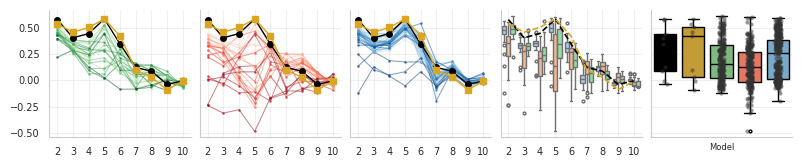

./data/pard3/pard3_regression_optimal/progen2-medium/progen2-medium_evaluation_train_on_2.csv


/tmp/ipykernel_3204533/2100133529.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


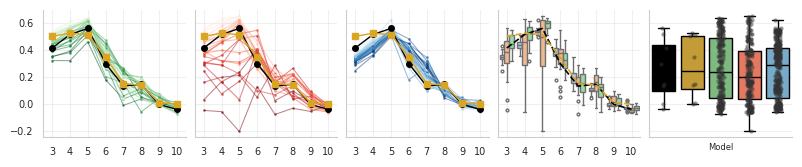

./data/pard3/pard3_regression_optimal/progen2-medium/progen2-medium_evaluation_train_on_3.csv


/tmp/ipykernel_3204533/2100133529.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


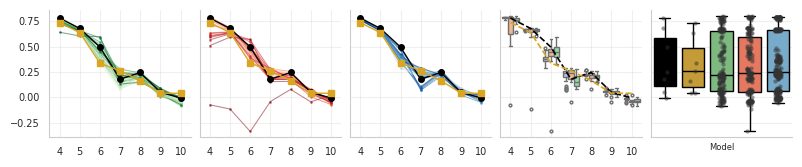

./data/pard3/pard3_regression_optimal/progen2-medium/progen2-medium_evaluation_train_on_4.csv


/tmp/ipykernel_3204533/2100133529.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


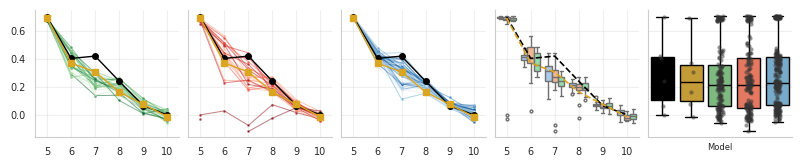

./data/pard3/pard3_regression_optimal/progen2-medium/progen2-medium_evaluation_train_on_5.csv


/tmp/ipykernel_3204533/2100133529.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


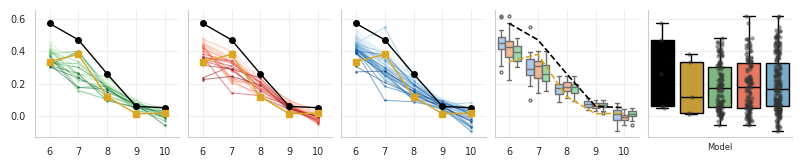

In [49]:
dataset_name = "pard3"
nmt_mut_range = np.arange(5,9)
pard3_mut_range = np.arange(1,6)

range_to_use = nmt_mut_range if dataset_name == "nmt" else pard3_mut_range
for num_muts in range_to_use:
    ohe_path = f"data/oracle_transfer_learning/{dataset_name}_trained_on_{num_muts}_ohe_results.csv"
    tl_path = f"data/oracle_transfer_learning/{dataset_name}_trained_on_{num_muts}_regular_tl_results.csv"
    delta_tl_path = f"data/oracle_transfer_learning/{dataset_name}_trained_on_{num_muts}_delta_tl_results.csv"

    ohe_df = pd.read_csv(ohe_path)
    tl_df = pd.read_csv(tl_path)
    delta_tl_df = pd.read_csv(delta_tl_path)

    ohe_df = ohe_df.rename(columns={"mlp_architecture": "architecture"})
    ohe_df = ohe_df[["architecture", "evaluated_test_mutation", "test_spearman"]]

    tl_df = tl_df.rename(columns={"pooling_method": "architecture"})
    tl_df = tl_df[["architecture", "evaluated_test_mutation", "test_spearman"]]

    delta_tl_df = delta_tl_df.rename(columns={"pooling_method": "architecture"})
    delta_tl_df["model"] = "delta_tl"
    delta_tl_df = delta_tl_df[["architecture", "evaluated_test_mutation", "test_spearman"]]

    delta_tl_df["model"] = "delta_embeddings"
    tl_df["model"] = "embeddings"
    ohe_df["model"] = "ohe"

    merged_df = pd.concat([ohe_df, tl_df, delta_tl_df], ignore_index=True)

    if dataset_name == "nmt":
        merged_df = merged_df[merged_df["evaluated_test_mutation"] >= 9]
        merged_df["test_spearman"] = merged_df["test_spearman"].abs()




    if dataset_name == "pard3":
        used_embeddings_path = f"./data/{dataset_name}/{dataset_name}_regression_optimal/progen2-medium/progen2-medium_evaluation_train_on_{num_muts}.csv"
        used_embeddings_df = pd.read_csv(used_embeddings_path)

        used_ohe_path = f"data/{dataset_name}/{dataset_name}_regression_optimal/one_hot/ohe_evaluation_train_on_{num_muts}.csv"
        used_ohe_df = pd.read_csv(used_ohe_path)
        print(used_embeddings_path)

        ohe_x = used_ohe_df["test_mutations"].to_numpy()
        ohe_y = used_ohe_df["correlation"].to_numpy()

        embeddings_x = used_embeddings_df["test_mutations"].to_numpy()
        embeddings_y = used_embeddings_df["correlation"].to_numpy()

    else:
        dataset = pd.read_csv("data/oracle_transfer_learning/nmt_baseline.csv")
        ohe_y = dataset[(dataset["train_mutations"] == num_muts) & (dataset["test_mutations"] >= 9)]["ohe_value"].to_numpy()
        ohe_x = dataset[(dataset["train_mutations"] == num_muts) & (dataset["test_mutations"] >= 9)]["test_mutations"].to_numpy()

        embeddings_y = dataset[(dataset["train_mutations"] == num_muts) & (dataset["test_mutations"] >= 9)]["llm_value"].to_numpy()
        embeddings_x = dataset[(dataset["train_mutations"] == num_muts) & (dataset["test_mutations"] >= 9)]["test_mutations"].to_numpy()




    merged_df = merged_df.reset_index(drop=True)

    fig, axes = plt.subplots(1, 5, figsize=(8, 1.65), sharey=True)

    models = ["delta_embeddings", "embeddings", "ohe"]
    palettes = {
        "delta_embeddings": "Greens",
        "embeddings": "Reds",
        "ohe": "Blues"
    }

    merged_df_no_dup = (
        merged_df
        .drop_duplicates(subset=["model", "architecture", "evaluated_test_mutation"])
        .reset_index(drop=True)
    )

    # --- Consistent x-axis tick positions ---
    all_xticks = sorted(
        set(merged_df_no_dup["evaluated_test_mutation"].unique())
        .union(set(ohe_x))
        .union(set(embeddings_x))
    )
    x_to_pos = {x: i for i, x in enumerate(all_xticks)}

    for idx, model in enumerate(models):
        ax = axes[idx]
        df_tmp = merged_df_no_dup[merged_df_no_dup["model"] == model].copy()

        # Assign x-position for all lines to get same x-axis ticks as boxplot
        df_tmp["x_pos"] = df_tmp["evaluated_test_mutation"].map(x_to_pos)
        # Some architectures may not exist at all x-positions, so mimic the ticks structure and missing data

        # Plot separate line for each architecture to preserve correct x-locations and missing points
        for arch, df_arch in df_tmp.groupby("architecture"):
            # Sort by x_pos so lines are connected left to right
            df_arch_sorted = df_arch.sort_values("x_pos")
            ax.plot(
                df_arch_sorted["x_pos"],
                df_arch_sorted["test_spearman"],
                marker="o",
                label=arch,
                color=sns.color_palette(palettes[model], n_colors=len(df_tmp["architecture"].unique()))[list(df_tmp["architecture"].unique()).index(arch)]
                if len(df_tmp["architecture"].unique()) > 1 else None,
                linewidth=0.75,
                markersize=1,
                alpha=0.5,
            )

        # Plot black OHE points at consistent x-positions
        ax.plot(
            [x_to_pos[x] for x in ohe_x],
            ohe_y,
            color="black",
            marker="o",
            linewidth=1,
            markersize=4,
            label="ohe_baseline"
        )

        # Plot goldenrod embeddings points at consistent x-positions
        ax.plot(
            [x_to_pos[x] for x in embeddings_x],
            embeddings_y,
            color="goldenrod",
            marker="s",
            linewidth=1,
            markersize=4,
            label="embeddings_baseline"
        )

        # No titles, no x-labels, no legends, fontsize 7
        ax.set_title("")
        ax.set_xlabel("")
        ax.set_ylabel("" if idx != 0 else "", fontsize=7)
        ax.tick_params(axis="both", which="major", labelsize=7)
        # Set the same tick positions and labels as boxplot (axes[3])
        ax.set_xticks(range(len(all_xticks)))
        ax.set_xticklabels(all_xticks, fontsize=7)
        ax.set_xlim(-0.5, len(all_xticks) - 0.5)
        leg = ax.get_legend()
        if leg is not None:
            leg.set_visible(False)
        # Remove top and right spines, add faded gridlines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", color="lightgrey", alpha=0.35, linestyle='-', linewidth=0.8, zorder=0)
        # Add light grid on x-axis as well
        ax.grid(axis="x", color="lightgrey", alpha=0.35, linestyle='-', linewidth=0.8, zorder=0)

    # -----------------------------------------
    # Subplot 4: boxplot by mutation and model
    # -----------------------------------------
    ax = axes[3]

    sns.boxplot(
        data=merged_df_no_dup,
        x="evaluated_test_mutation",
        y="test_spearman",
        hue="model",
        ax=ax,
        palette="pastel",
        order=all_xticks,
        legend=False,
        fliersize=2,
        linewidth=1
    )

    ohe_x_pos = [x_to_pos[x] for x in ohe_x]
    embeddings_x_pos = [x_to_pos[x] for x in embeddings_x]

    ax.plot(
        ohe_x_pos,
        ohe_y,
        color="black",
        marker="o",
        linestyle="--",
        linewidth=1.2,
        markersize=0,
        zorder=10,
    )

    ax.plot(
        embeddings_x_pos,
        embeddings_y,
        color="goldenrod",
        marker="s",
        linestyle="--",
        linewidth=1.2,
        markersize=0,
        zorder=10,
    )

    ax.set_xticks(range(len(all_xticks)))
    ax.set_xticklabels(all_xticks, fontsize=7)
    ax.set_xlim(-0.5, len(all_xticks) - 0.5)
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("", fontsize=7)
    ax.tick_params(axis="both", which="major", labelsize=7)
    legend = ax.get_legend()
    if legend is not None:
        legend.set_visible(False)
    # Remove top and right spines, add faded gridlines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="lightgrey", alpha=0.35, linestyle='-', linewidth=0.8, zorder=0)
    ax.grid(axis="x", color="lightgrey", alpha=0.35, linestyle='-', linewidth=0.8, zorder=0)

    # -----------------------------------------
    # Subplot 5: pooled comparison across all x
    # -----------------------------------------
    ax = axes[4]

    compare_df = pd.concat(
        [
            pd.DataFrame({
                "group": "OHE Baseline",
                "test_spearman": np.asarray(ohe_y),
            }),
            pd.DataFrame({
                "group": "Embeddings Baseline",
                "test_spearman": np.asarray(embeddings_y),
            }),
            merged_df_no_dup.loc[
                merged_df_no_dup["model"] == "delta_embeddings",
                ["test_spearman"]
            ].assign(group="Delta Embeddings"),
            merged_df_no_dup.loc[
                merged_df_no_dup["model"] == "embeddings",
                ["test_spearman"]
            ].assign(group="Embeddings"),
            merged_df_no_dup.loc[
                merged_df_no_dup["model"] == "ohe",
                ["test_spearman"]
            ].assign(group="OHE"),
        ],
        ignore_index=True,
    )

    group_order = [
        "OHE Baseline",
        "Embeddings Baseline",
        "Delta Embeddings",
        "Embeddings",
        "OHE",
    ]
    group_palette = ["black", "goldenrod", "#74c476", "#fb6a4a", "#6baed6"]

    # Create boxplot (no x-labels)
    sns.boxplot(
        data=compare_df,
        x="group",
        y="test_spearman",
        order=group_order,
        palette=group_palette,
        ax=ax,
        fliersize=2,
        linewidth=1
    )

    sns.stripplot(
        data=compare_df,
        x="group",
        y="test_spearman",
        order=group_order,
        color="0.2",
        alpha=0.5,
        size=3,
        ax=ax,
    )

    # Remove all x-labels: ticks and axis label
    ax.set_title("")
    ax.set_xlabel("Model")  # Remove x-label
    ax.set_ylabel("", fontsize=7)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    if ax.get_legend() is not None:
        ax.get_legend().set_visible(False)
    # Remove top and right spines, add faded gridlines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="lightgrey", alpha=0.35, linestyle='-', linewidth=0.8, zorder=0)
    ax.grid(axis="x", color="lightgrey", alpha=0.35, linestyle='-', linewidth=0.8, zorder=0)

    for ax_ in axes:
        for label in (ax_.get_xticklabels() + ax_.get_yticklabels()):
            label.set_fontsize(7)

    plt.tight_layout()
    plt.show()

    source_group = f"{dataset}_trained_on_{num_muts}"

    aggregated_compare_df, best_arch_across_groups_df = append_best_model_points_to_aggregate(
        aggregated_compare_df=aggregated_compare_df,
        best_arch_across_groups_df=best_arch_across_groups_df,
        merged_df=merged_df,
        embeddings_x=embeddings_x,
        embeddings_y=embeddings_y,
        ohe_x=ohe_x,
        ohe_y=ohe_y,
        source_group=source_group,
    )



Pooled ANOVA:
Best Delta Embeddings: n=35, mean=0.3038
Best Embeddings: n=35, mean=0.3063
Embeddings Baseline: n=35, mean=0.2684
F = 0.2736, p = 0.7612

Pooled paired t-test: Best OHE vs OHE Baseline
n_pairs = 35
mean(best_ohe) = 0.2973
mean(ohe_baseline) = 0.2916
t = 0.4545, p = 0.6523


/tmp/ipykernel_3204533/1875030090.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


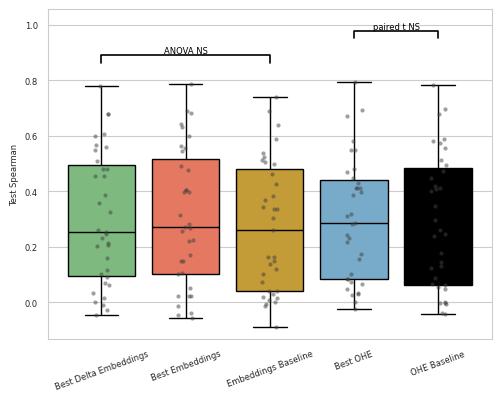

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_rel

def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "NS"


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", color="black")


plot_order = [
    "Best Delta Embeddings",
    "Best Embeddings",
    "Embeddings Baseline",
    "Best OHE",
    "OHE Baseline",
]

palette = {
    "Best Delta Embeddings": "#74c476",
    "Best Embeddings": "#fb6a4a",
    "Embeddings Baseline": "goldenrod",
    "Best OHE": "#6baed6",
    "OHE Baseline": "black",
}

# -----------------------------
# Pooled ANOVA
# -----------------------------
anova_df = aggregated_compare_df[
    aggregated_compare_df["comparison_group"].isin(
        ["best_delta_embeddings", "best_embeddings", "embeddings_baseline"]
    )
].copy()

anova_groups = {
    "Best Delta Embeddings": anova_df.loc[
        anova_df["comparison_group"] == "best_delta_embeddings", "test_spearman"
    ].dropna().to_numpy(),
    "Best Embeddings": anova_df.loc[
        anova_df["comparison_group"] == "best_embeddings", "test_spearman"
    ].dropna().to_numpy(),
    "Embeddings Baseline": anova_df.loc[
        anova_df["comparison_group"] == "embeddings_baseline", "test_spearman"
    ].dropna().to_numpy(),
}

f_stat, anova_p = f_oneway(
    anova_groups["Best Delta Embeddings"],
    anova_groups["Best Embeddings"],
    anova_groups["Embeddings Baseline"],
)

print("Pooled ANOVA:")
for name, vals in anova_groups.items():
    print(f"{name}: n={len(vals)}, mean={np.mean(vals):.4f}")
print(f"F = {f_stat:.4f}, p = {anova_p:.4g}")

# -----------------------------
# Pooled paired t-test
# Pair on (source_group, evaluated_test_mutation)
# -----------------------------
paired_ohe_df = aggregated_compare_df[
    aggregated_compare_df["comparison_group"].isin(["best_ohe", "ohe_baseline"])
][
    ["source_group", "evaluated_test_mutation", "comparison_group", "test_spearman"]
].copy()

paired_ohe_wide = (
    paired_ohe_df
    .pivot_table(
        index=["source_group", "evaluated_test_mutation"],
        columns="comparison_group",
        values="test_spearman",
        aggfunc="mean",
    )
    .dropna()
    .reset_index()
)

t_stat, ttest_p = ttest_rel(
    paired_ohe_wide["best_ohe"],
    paired_ohe_wide["ohe_baseline"],
)

print("\nPooled paired t-test: Best OHE vs OHE Baseline")
print(f"n_pairs = {len(paired_ohe_wide)}")
print(f"mean(best_ohe) = {paired_ohe_wide['best_ohe'].mean():.4f}")
print(f"mean(ohe_baseline) = {paired_ohe_wide['ohe_baseline'].mean():.4f}")
print(f"t = {t_stat:.4f}, p = {ttest_p:.4g}")

# -----------------------------
# Plot pooled aggregated points
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=aggregated_compare_df,
    x="display_group",
    y="test_spearman",
    order=plot_order,
    palette=palette,
    ax=ax,
)

sns.stripplot(
    data=aggregated_compare_df,
    x="display_group",
    y="test_spearman",
    order=plot_order,
    color="0.25",
    alpha=0.5,
    size=3,
    ax=ax,
)

y_max = aggregated_compare_df["test_spearman"].max()
y_min = aggregated_compare_df["test_spearman"].min()
y_range = y_max - y_min if y_max > y_min else 1.0

add_sig_bracket(
    ax,
    0,
    2,
    y_max + 0.08 * y_range,
    0.03 * y_range,
    f"ANOVA {p_to_stars(anova_p)}",
)

add_sig_bracket(
    ax,
    3,
    4,
    y_max + 0.18 * y_range,
    0.03 * y_range,
    f"paired t {p_to_stars(ttest_p)}",
)

ax.set_xlabel("")
ax.set_ylabel("Test Spearman")
ax.tick_params(axis="x", rotation=20)
ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.30 * y_range)

plt.tight_layout()
plt.show()
